In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import squarify
import yfinance as yf
import seaborn as sb

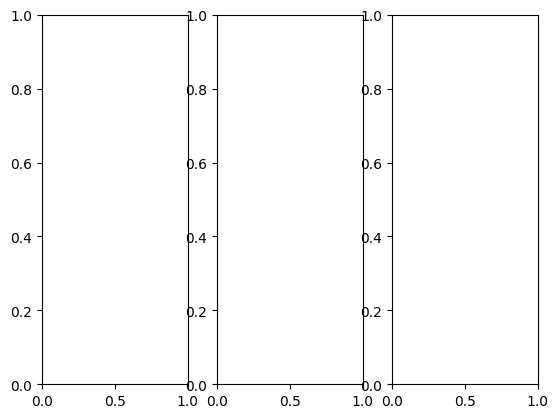

In [2]:
figure, axis = plt.subplots(1, 3)

In [8]:
df = pd.read_csv('portfolio.csv')
df_ira = pd.read_csv('portfolio_ira.csv')

# Function to fetch the current stock price using yfinance
def get_stock_price(ticker):
    stock = yf.Ticker(ticker)
    price = stock.history(period="1d")['Close'].iloc[-1]  # Get the latest closing price
    return price

# Create a new column 'Equity' by fetching the stock price and multiplying by share count
def add_equity_column(df):
    df['Equity'] = df.apply(lambda row: get_stock_price(row['Ticker']) * row['Shares'], axis=1)
    df['Equity'] = round(df['Equity'], 2)

# Print total equity
def print_equity(df):
    print(f'Total: ${round(df["Equity"].sum(), 2)}')

add_equity_column(df)
add_equity_column(df_ira)

print(df)
print_equity(df)

print(df_ira)
print_equity(df_ira)


   Ticker     Shares  Equity
0    RKLB  80.780000  903.12
1    HOOD  25.620000  693.28
2    PLTR   9.280000  416.30
3    META   0.682164  391.05
4    DPST   3.000000  312.93
5    NVDA   2.230000  315.63
6    TSLA   0.935921  251.94
7     SLG   2.860000  219.10
8    GRND   8.320000  109.24
9    SOFI  10.000000  109.90
10   OKLO   4.820000   92.11
11     MO   2.010000   99.92
12    PLD   0.789515   92.80
13    AMD   0.611010   95.46
14   INTC   2.100000   47.63
15   BABA   0.490070   47.74
16    MCD   0.015887    4.65
Total: $4202.8
   Ticker      Shares   Equity
0    PLTR  112.820000  5061.11
1    TSLA   14.680000  3951.71
2    HOOD  116.550000  3153.84
3    META    5.230000  2998.10
4    NVDA   18.270000  2585.94
5    RKLB  185.540000  2074.34
6     SLG   19.730000  1511.52
7    QQQM    6.050000  1233.29
8     AMD    5.940000   928.01
9     VOO    1.550000   825.00
10   SOFI   38.730000   425.64
11   NTLA   23.210000   370.20
12     SQ    4.690000   340.54
13     PM    2.510000   325.9

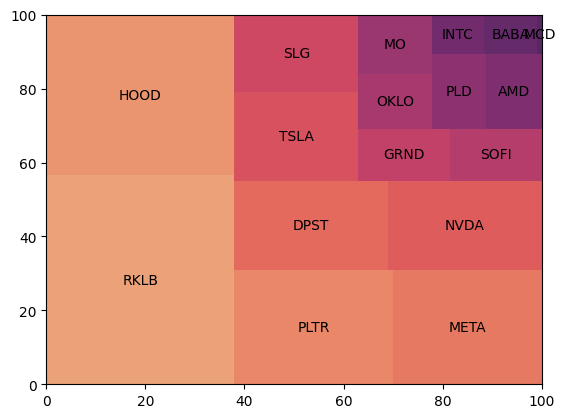

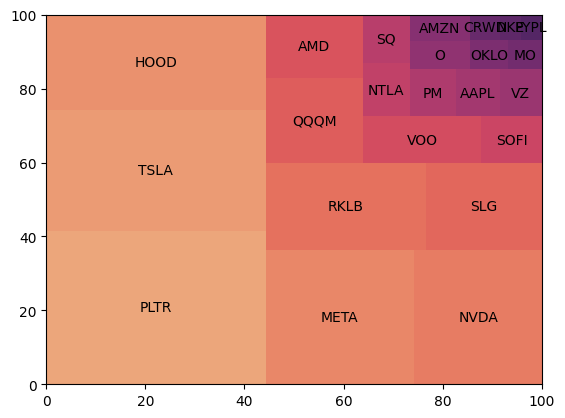

In [12]:
# squarify.plot(label=[f'{name}:{round(amount)}' for name, amount in zip(df.Name, df.Amount)], sizes=df.Amount, color=sb.color_palette("flare",len(df)), alpha=0.8)
def squarify_plot(df):
    squarify.plot(label=df.Ticker, sizes=df.Equity, color=sb.color_palette("flare",len(df)))
    plt.show()

squarify_plot(df)
squarify_plot(df_ira)